# Chapter 04 — Ensembles and Restarts: an NPT sketch in mdlite, LAMMPS's fix npt, and restart continuation

*lammps-skill 0.1.25. Generated by `build/assemble.py` — do not edit this notebook; edit `build/chapter04_ensembles_restarts.py` and re-assemble.*

**Needs a LAMMPS installation:** yes

## Contents

1. [](#)
2. [](#)
3. [](#)
4. [](#)
5. [](#)
6. [](#)

In [1]:
# Setup -- run me first.
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the product root, when run from chapters/

from IPython.display import display, HTML

import lammpskill
from lammpskill.install import detect_all

print("lammps-skill", lammpskill.__version__, "| python", sys.version.split()[0])
INSTALLATIONS = detect_all()
if INSTALLATIONS:
    for i in INSTALLATIONS:
        print("  %-11s %-24s %s" % (i.route, i.version, i.executable or "(library only)"))
else:
    print("  no LAMMPS installation detected -- chapters marked 'no LAMMPS needed' still run;")
    print("  the others load their recorded results instead (record-or-run).")

_FIG = {"n": 0}                # this chapter's own figure count -- chapters are self-contained

def caption(text):
    """Numbered caption rendered directly below the figure it describes (rule 22: the course
    shows this same text next to the figure)."""
    _FIG["n"] += 1
    display(HTML(
        "<div style='max-width:780px;margin:2px 0 14px 12px;font-size:0.92em;"
        "color:#444;border-left:3px solid #bbb;padding-left:10px'>"
        "<b>Figure %d.</b> %s</div>" % (_FIG["n"], text)))

lammps-skill 0.1.25 | python 3.12.14


  wsl-apt     10 Dec 2025              /usr/bin/lmp
  wsl-source  22 Jul 2025 - Update 6   /home/fabio/.local/bin/lmp_core


## Two ways state outlives one `run`

An NPT ensemble lets the box respond to a target pressure instead of holding it fixed; a restart
lets a simulation stop and pick up again as if it never had. Both are about state that survives
past the boundary of a single `run` command -- one across an ensemble, one across a process.

## The mdlite NPT sketch, and its limits

`mdlite.npt.BerendsenBarostat` rescales the box toward a target pressure by weak coupling
(Berendsen et al. 1984) -- the same trade `mdlite.thermostats.Berendsen` makes for temperature.
**State plainly: this is not a fluctuating-cell method.** There is no Parrinello-Rahman or
Martyna-Tuckerman-Klein cell mass, and it does not sample the isothermal-isobaric ensemble
correctly -- it relaxes the box toward the target and holds it there. That is enough to show what
NPT is *for* (a system finds its own equilibrium volume at a given pressure, rather than being told
one), not a claim that this is a research-grade barostat.

In [2]:
import numpy as np

from mdlite.box import Box
from mdlite.integrate import State
from mdlite.neighbors import VerletList
from mdlite.npt import BerendsenBarostat, velocity_verlet_npt
from mdlite.pair import LennardJones
from mdlite.thermostats import Berendsen


def fcc(n, rho):
    a = (4.0 / rho) ** (1.0 / 3.0)
    base = np.array([[0, 0, 0], [0.5, 0.5, 0], [0.5, 0, 0.5], [0, 0.5, 0.5]]) * a
    cells = np.array([[i, j, k] for i in range(n) for j in range(n) for k in range(n)]) * a
    return (cells[:, None, :] + base[None, :, :]).reshape(-1, 3), Box([n * a] * 3)


# start denser than the target pressure equilibrates to -- the box should expand.
pos, box = fcc(3, 1.1)
rng = np.random.default_rng(3)
vel = rng.normal(0, np.sqrt(2.0), pos.shape)
vel -= vel.mean(0)
st = State(pos, vel, 1.0, box)
vl = VerletList(box, 2.5)
rec_npt = velocity_verlet_npt(st, [LennardJones()], dt=0.005, nsteps=1500, nlist=vl, thermostat=Berendsen(2.0, 0.5),
                               barostat=BerendsenBarostat(P0=1.0, tau=2.0), every=15)
V = np.array([r["V"] for r in rec_npt])
P = np.array([r["P"] for r in rec_npt])
print("volume: start=%.2f  end=%.2f  (expect expansion toward the lower target pressure)" % (V[0], V[-1]))
print("pressure: start=%.3f  end (last 10 avg)=%.3f  (target 1.0)" % (P[0], P[-10:].mean()))
assert V[-1] > V[0]

volume: start=98.18  end=238.27  (expect expansion toward the lower target pressure)
pressure: start=4.258  end (last 10 avg)=0.953  (target 1.0)


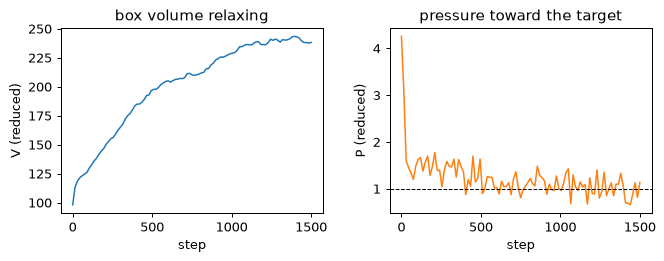

In [3]:
import matplotlib.pyplot as plt

step = [r["step"] for r in rec_npt]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.5, 3), dpi=90)
ax1.plot(step, V, lw=1.2)
ax1.set_xlabel("step"); ax1.set_ylabel("V (reduced)"); ax1.set_title("box volume relaxing")
ax2.plot(step, P, lw=1.2, color="tab:orange")
ax2.axhline(1.0, color="k", ls="--", lw=0.8)
ax2.set_xlabel("step"); ax2.set_ylabel("P (reduced)"); ax2.set_title("pressure toward the target")
fig.tight_layout()
plt.show()
caption("The NPT run started denser than its target pressure: box volume expands (left) while "
        "the instantaneous pressure relaxes down toward the target of 1.0 (right, dashed) under "
        "the Berendsen barostat.")

## The same idea in LAMMPS: `fix npt`

LAMMPS's `fix npt` couples a Nosé–Hoover chain on *both* temperature and pressure -- a real
fluctuating-cell method, not a sketch. Record-or-run gives a live number when LAMMPS is present.

In [4]:
import tempfile

from lammpskill.run import run, run_or_load
from lammpskill.script import Spec, Stage

npt_spec = Spec(
    units="lj", atom_style="atomic", lattice="fcc 1.1", region="box block 0 5 0 5 0 5",
    create_box=1, create_atoms="1 box", masses={1: 1.0}, pair_style="lj/cut 2.5", pair_coeffs=["1 1 1.0 1.0 2.5"],
    neighbor="0.3 bin", neigh_modify="every 20 delay 0 check no",
    velocity=["all create 2.0 4242 loop geom"], timestep=0.005,
    fixes=["1 all npt temp 2.0 2.0 0.5 iso 1.0 1.0 2.0"], thermo=50, thermo_style="custom step temp press vol",
    stages=[Stage("run", "1500")], comment="LJ, fix npt from a compressed start -- same target pressure as the mdlite sketch above",
)


def compute_npt():
    workdir = tempfile.mkdtemp(prefix="ch04_npt_")
    result = run(npt_spec, workdir, time_limit=300)
    if not result.ok:
        raise RuntimeError("fix npt run failed (rc=%s): %s" % (result.returncode, "; ".join(result.errors) or result.stderr))
    t = result.thermo
    vol, press = t.get("Volume") if "Volume" in t.columns else t.get("Vol"), t.get("Press")
    n_tail = max(1, len(vol) // 4)
    return {"natoms": t.natoms, "route": result.installation.route if result.installation else None,
            "V_start": float(vol[0]), "V_end_mean": float(vol[-n_tail:].mean()),
            "P_end_mean": float(press[-n_tail:].mean())}


npt_rec = run_or_load("lj_npt_ch04", compute_npt, records_dir="../data/records")
print("source:", npt_rec["source"])
if npt_rec["source"] != "skip":
    print("route:", npt_rec.get("route"))
    print("LAMMPS fix npt: V start=%.2f -> end (last quarter avg)=%.2f, P end (last quarter avg)=%.3f (target 1.0)"
          % (npt_rec["V_start"], npt_rec["V_end_mean"], npt_rec["P_end_mean"]))
else:
    print("no LAMMPS available and no record yet:", npt_rec.get("reason"))

source: record
route: wsl-apt
LAMMPS fix npt: V start=454.55 -> end (last quarter avg)=1066.64, P end (last quarter avg)=1.197 (target 1.0)


## Watching the box relax -- and the lattice melt

The plot above shows volume and pressure as numbers; here is the atom-level picture, and it is
not only a box relaxing. The density drops from rho*=1.1 to rho*=0.45 over this run -- an fcc
lattice at rho*=1.1 does not just spread out at fix npt's T*=2.0 target, it disorders. Comparing
the same atoms' displacement to what pure affine box expansion alone would produce (scale
positions by the box's own growth, about its fixed geometric centre, then take the residual)
shows real rearrangement on top of the expansion, not just dilation. Unlike chapter 03's
fixed-volume NVT, `fix npt` actually changes the box size step by step, so
`lammpskill.viz.animate_gif` (one fixed cell for every frame) does not fit -- instead, two
**static** snapshots, one at the compressed start and one at the expanded end, each with its own
(different-sized) box: the same before/after technique chapter 05 uses for the vacancy
relaxation. Both frames show the same 150 atoms (tracked by id, wrapped into their own frame's
box so none render as having escaped it). **Matplotlib auto-scales each panel to its own
content, so the two images below are not directly comparable in apparent size** -- the box's
real growth is the number in the volume plot above, not something to read off these pictures.

In [5]:
import dataclasses
import os
import tempfile

import numpy as np

from lammpskill.io.dump import read_dump
from lammpskill.run import run, run_or_load

DUMP_EVERY = 50

# the identical fix npt case above (dataclasses.replace, not a hand-retyped Spec), plus a
# trajectory dump for the atom views
npt_traj_spec = dataclasses.replace(
    npt_spec,
    dumps=["1 all custom %d traj.dump id type xu yu zu" % DUMP_EVERY],
    comment="the same fix npt case above, with a trajectory dump for the atom views",
)


def compute_npt_traj():
    workdir = tempfile.mkdtemp(prefix="ch04_traj_")
    result = run(npt_traj_spec, workdir, time_limit=300)
    if not result.ok:
        raise RuntimeError("npt trajectory run failed (rc=%s): %s" % (result.returncode, "; ".join(result.errors) or result.stderr))
    traj = read_dump(os.path.join(workdir, "traj.dump"))
    first, last = traj.frames[0].sorted_by_id(), traj.frames[-1].sorted_by_id()
    # the bottom 20% of the box height, by the FIRST frame's own (compressed) box -- a fraction of
    # a changing box, not a fixed lattice-spacing threshold like chapter 01/03 use on a fixed box
    z0 = first.positions[:, 2]
    idx = np.nonzero(z0 < 0.2 * first.box.lengths[2])[0]
    pos_start = first.positions[idx]
    # xu/yu/zu are unwrapped: by the end, some of these atoms have drifted outside the (also
    # larger) end box -- wrap into the end frame's own bounds so the render shows real periodic
    # images, not atoms that look like they escaped the box (found live: 116/150 did, unwrapped)
    pos_end = last.box.wrap(last.positions[idx])

    # how much of the displacement is genuine rearrangement, not just the box's own affine
    # dilation: fix npt's iso coupling rescales symmetrically about the box's fixed geometric
    # centre (verified: centre_start == centre_end here), so map pos_start through that same
    # affine transform, then take the minimum-image residual against the (wrapped) end positions
    centre_start = (first.box.lo + first.box.hi) / 2.0
    centre_end = (last.box.lo + last.box.hi) / 2.0
    scale = last.box.lengths / first.box.lengths
    pos_start_affine = centre_end + (pos_start - centre_start) * scale
    residual = last.box.minimum_image(pos_end - pos_start_affine)
    disorder_rmsd = float(np.sqrt((residual ** 2).sum(axis=1).mean()))
    a_start = first.box.lengths[0] / 5.0   # region is 5x5x5 unit cells; a is the fcc lattice constant
    nn_scaled = float(a_start / np.sqrt(2.0) * scale[0])   # nearest-neighbour spacing, affinely scaled

    return {"natoms_shown": len(idx),
            "route": result.installation.route if result.installation else None,
            "pos_start": pos_start.tolist(), "cell_start": first.box.lengths.tolist(),
            "pos_end": pos_end.tolist(), "cell_end": last.box.lengths.tolist(),
            "disorder_rmsd": disorder_rmsd, "nn_scaled": nn_scaled}


npt_traj_rec = run_or_load("lj_npt_traj_ch04", compute_npt_traj, records_dir="../data/records")
print("source:", npt_traj_rec["source"], "| atoms shown:", npt_traj_rec.get("natoms_shown"))
if npt_traj_rec["source"] != "skip":
    print("disorder beyond pure affine expansion: RMS %.3f (affinely-scaled nearest-neighbour spacing: %.3f)"
          % (npt_traj_rec["disorder_rmsd"], npt_traj_rec["nn_scaled"]))

source: run | atoms shown: 150
disorder beyond pure affine expansion: RMS 3.111 (affinely-scaled nearest-neighbour spacing: 1.464)


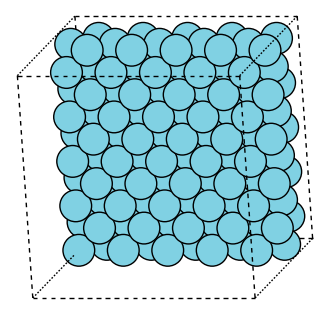

In [6]:
import matplotlib.pyplot as plt

from lammpskill import viz

if npt_traj_rec["source"] != "skip":
    try:
        fig = viz.snapshot(np.array(npt_traj_rec["pos_start"]), np.array(npt_traj_rec["cell_start"]),
                           symbols=["Ar"] * npt_traj_rec["natoms_shown"])
    except ImportError as e:
        print("ase not installed -- skipping the npt snapshots:", e)
    else:
        plt.show()
        caption("150 atoms from the compressed starting configuration (fcc 1.1) -- perfectly "
                "ordered, before fix npt has taken a single step -- rendered as argon-like "
                "spheres, the reduced-units convention chapter 01 established.")
else:
    print("no LAMMPS and no record: nothing to show")

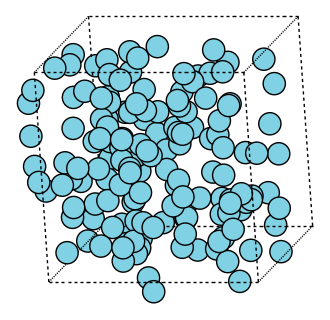

In [7]:
if npt_traj_rec["source"] != "skip":
    try:
        fig = viz.snapshot(np.array(npt_traj_rec["pos_end"]), np.array(npt_traj_rec["cell_end"]),
                           symbols=["Ar"] * npt_traj_rec["natoms_shown"])
    except ImportError as e:
        print("ase not installed -- skipping the npt snapshots:", e)
    else:
        plt.show()
        caption("The same 150 atoms (tracked by id, not re-selected) after fix npt has run: "
                "visibly scattered, not merely spread apart on the same lattice -- the measured "
                "disorder (RMS %.2f beyond pure affine box expansion) exceeds the affinely-scaled "
                "nearest-neighbour spacing (%.2f), so this is a real rearrangement, not only the "
                "box growth the volume plot above reports as a number." %
                (npt_traj_rec["disorder_rmsd"], npt_traj_rec["nn_scaled"]))
else:
    print("no LAMMPS and no record: nothing to show")

## Restart continuation

A `Spec` with `read_restart` in `pre` runs before the auto-generated `units` line -- which is
exactly the problem: `read_restart` defines the box, and LAMMPS refuses a `units` command once the
box exists (`ERROR: Units command after simulation box is defined`, hit while writing this
chapter). `Spec.units` accepts `None` for exactly this case -- it omits the line entirely, since the
restart file already carries the units. Nothing else the restart carries (box, atoms, velocities)
needs to be declared again; only the settings a restart does not always carry (pair style and
coefficients here) are repeated.

In [8]:
def compute_restart():
    workdir = tempfile.mkdtemp(prefix="ch04_restart_")
    stage_a = Spec(
        units="lj", atom_style="atomic", lattice="fcc 0.8442", region="box block 0 5 0 5 0 5",
        create_box=1, create_atoms="1 box", masses={1: 1.0}, pair_style="lj/cut 2.5", pair_coeffs=["1 1 1.0 1.0 2.5"],
        neighbor="0.3 bin", neigh_modify="every 20 delay 0 check no",
        velocity=["all create 2.0 12345 loop geom"], timestep=0.005, fixes=["1 all nve"],
        thermo=50, thermo_style="custom step temp pe etotal", stages=[Stage("run", "300")],
        post=["write_restart stage_a.restart"], comment="stage A: 300 steps, then checkpoint",
    )
    res_a = run(stage_a, workdir, time_limit=300)
    if not res_a.ok:
        raise RuntimeError("restart stage A failed: %s" % (res_a.errors or res_a.stderr))

    stage_b = Spec(
        units=None, pre=["read_restart stage_a.restart"],
        pair_style="lj/cut 2.5", pair_coeffs=["1 1 1.0 1.0 2.5"],
        neighbor="0.3 bin", neigh_modify="every 20 delay 0 check no",
        timestep=0.005, fixes=["1 all nve"], thermo=50, thermo_style="custom step temp pe etotal",
        stages=[Stage("run", "300")], comment="stage B: continue from the restart for 300 more steps",
    )
    res_b = run(stage_b, workdir, time_limit=300, input_name="in.b.lammps", log_name="log.b.lammps")
    if not res_b.ok:
        raise RuntimeError("restart stage B failed: %s" % (res_b.errors or res_b.stderr))

    return {"route": res_a.installation.route if res_a.installation else None,
            "step_a_final": res_a.thermo.last.get("Step"), "step_b_final": res_b.thermo.last.get("Step"),
            "temp_a_final": res_a.thermo.last.get("Temp"), "temp_b_final": res_b.thermo.last.get("Temp")}


restart_rec = run_or_load("lj_restart_ch04", compute_restart, records_dir="../data/records")
print("source:", restart_rec["source"])
if restart_rec["source"] != "skip":
    print("route:", restart_rec.get("route"))
    print("stage A ended at step %s (T=%.3f); stage B, continued from the restart, ended at step %s (T=%.3f)"
          % (restart_rec["step_a_final"], restart_rec["temp_a_final"], restart_rec["step_b_final"], restart_rec["temp_b_final"]))
    assert restart_rec["step_b_final"] == restart_rec["step_a_final"] + 300
else:
    print("no LAMMPS available and no record yet:", restart_rec.get("reason"))

source: record
route: wsl-apt
stage A ended at step 300.0 (T=1.036); stage B, continued from the restart, ended at step 600.0 (T=1.019)


## Reading it

- The mdlite sketch and `fix npt` are answering the same question -- "what volume does this system
  settle at, at this pressure" -- with methods of very different rigor. Comparing them is a check
  on the *sketch's direction*, not a claim they agree quantitatively.
- A restart file is not a snapshot a script can casually reconstruct: `stage_b` above declares only
  what the restart does not carry (pair style, coefficients), and the checker (chapter 01) would
  flag it as `read_data`-shaped if it tried to re-declare the box.
- Both mechanisms exist for the same underlying reason as `run_or_load` itself: a long computation
  should not have to happen exactly once, in exactly one process, to be usable.

In [9]:
# Tally -- what this chapter claimed, checked.
checks = []
checks.append(('the mdlite NPT sketch expanded a compressed system toward its lower target pressure', bool(V[-1] > V[0])))
checks.append(('run_or_load (fix npt) returned one of its three documented outcomes', bool(npt_rec['source'] in ('run', 'record', 'skip'))))
checks.append(('run_or_load (restart) returned one of its three documented outcomes', bool(restart_rec['source'] in ('run', 'record', 'skip'))))
checks.append(('run_or_load (npt trajectory) returned one of its three documented outcomes', bool(npt_traj_rec['source'] in ('run', 'record', 'skip'))))
checks.append(("the box actually grew, not just the atoms' positions", bool(npt_traj_rec['source'] == 'skip' or np.array(npt_traj_rec['cell_end'])[2] > np.array(npt_traj_rec['cell_start'])[2])))
checks.append(('the shown atoms rearranged by more than one affinely-scaled nearest-neighbour spacing -- genuine disorder, not just box dilation', bool(npt_traj_rec['source'] == 'skip' or npt_traj_rec['disorder_rmsd'] > npt_traj_rec['nn_scaled'])))

for label, ok in checks:
    print(('PASS' if ok else 'FAIL'), label)
assert all(ok for _, ok in checks), 'chapter 04: a claim above is not true'
print('chapter 04: %d claim(s) checked' % len(checks))

PASS the mdlite NPT sketch expanded a compressed system toward its lower target pressure
PASS run_or_load (fix npt) returned one of its three documented outcomes
PASS run_or_load (restart) returned one of its three documented outcomes
PASS run_or_load (npt trajectory) returned one of its three documented outcomes
PASS the box actually grew, not just the atoms' positions
PASS the shown atoms rearranged by more than one affinely-scaled nearest-neighbour spacing -- genuine disorder, not just box dilation
chapter 04: 6 claim(s) checked
